In [1]:
# Physics-Informed MLP Model for ERA5 Wave Spectra (with all directional moments)
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load processed data
data_path = "data\processed"
arrays = []

# Load all processed files
for file in os.listdir(data_path):
    print(f"Processing file: {file}")
    full_path = os.path.join(data_path, file)
    print(f"Loading {file}")
    data = np.load(full_path, allow_pickle=False)
    print(f"  Keys: {list(data.keys())}")
    print(f"  X shape: {data['X'].shape}")
    print(f"  y shape: {data['y'].shape}")
    arrays.append(data)

# Combine all samples
total_samples = sum(len(arr['X']) for arr in arrays)
print(f"Total samples: {total_samples}")

# Initialize arrays for combined data
combined_X = []
combined_y = []

for arr in arrays:
    combined_X.append(arr['X'])
    combined_y.append(arr['y'])

# Convert to numpy arrays and extract features
X_combined = np.concatenate(combined_X, axis=0)  # Shape: (samples, 5, 30)
y_combined = np.concatenate(combined_y, axis=0)  # Shape: (samples, 30, 24)

# Extract ALL components from X (use ALL 5 components: S1D, a1, b1, a2, b2)
S1D = X_combined[:, 0, :]  # 1D spectra: (samples, 30)
a1 = X_combined[:, 1, :]   # Directional moment a1: (samples, 30)  
b1 = X_combined[:, 2, :]   # Directional moment b1: (samples, 30)
a2 = X_combined[:, 3, :]   # Directional moment a2: (samples, 30) - INCLUDED
b2 = X_combined[:, 4, :]   # Directional moment b2: (samples, 30) - INCLUDED
S2D = y_combined           # 2D spectra: (samples, 30, 24)

print(f"Data shapes:")
print(f"S1D: {S1D.shape}")  
print(f"S2D: {S2D.shape}")
print(f"a1: {a1.shape}")
print(f"b1: {b1.shape}")
print(f"a2: {a2.shape}")   # NEW
print(f"b2: {b2.shape}")   # NEW

# Check for any NaN values in loaded data
print(f"NaN values in S1D: {np.isnan(S1D).sum()}")
print(f"NaN values in S2D: {np.isnan(S2D).sum()}")
print(f"NaN values in a1: {np.isnan(a1).sum()}")
print(f"NaN values in b1: {np.isnan(b1).sum()}")
print(f"NaN values in a2: {np.isnan(a2).sum()}")  # NEW
print(f"NaN values in b2: {np.isnan(b2).sum()}")  # NEW

Processing file: era5_wave_training.npz
Loading era5_wave_training.npz
  Keys: ['X', 'y', 'freq_hz', 'direction_deg', 'valid_time']
  X shape: (9504, 5, 30)
  y shape: (9504, 30, 24)
Total samples: 9504
Data shapes:
S1D: (9504, 30)
S2D: (9504, 30, 24)
a1: (9504, 30)
b1: (9504, 30)
a2: (9504, 30)
b2: (9504, 30)
NaN values in S1D: 0
NaN values in S2D: 0
NaN values in a1: 0
NaN values in b1: 0
NaN values in a2: 0
NaN values in b2: 0


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8568\615587787.py:2: SyntaxWarning: invalid escape sequence '\p'
  data_path = "data\processed"


In [3]:
# Prepare inputs for Physics-Informed MLP model (ALL moments)
print("Preparing inputs for Physics-Informed MLP model...")

# Create model inputs by concatenating ALL features
# Input features: S1D (30) + a1 (30) + b1 (30) + a2 (30) + b2 (30) = 150 features
batch_size, n_freq, n_dir = S2D.shape
n_features = n_freq * 5  # ALL 5 components

# Flatten and concatenate ALL inputs
inputs = np.concatenate([
    S1D.reshape(batch_size, -1),  # Shape: (batch_size, 30)  
    a1.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    b1.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    a2.reshape(batch_size, -1),   # Shape: (batch_size, 30) - NEW
    b2.reshape(batch_size, -1)    # Shape: (batch_size, 30) - NEW
], axis=1)  # Final shape: (batch_size, 150)

# Target is the FULL 2D spectrum (direct regression with physics constraints)
targets = S2D.reshape(batch_size, -1)  # Shape: (batch_size, 30*24=720)

print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")
print(f"Input features: {n_features} (S1D + a1 + b1 + a2 + b2)")

# Check for any remaining NaN values
nan_inputs = np.isnan(inputs).sum()
nan_targets = np.isnan(targets).sum()
print(f"NaN in inputs: {nan_inputs}")
print(f"NaN in targets: {nan_targets}")

if nan_inputs > 0 or nan_targets > 0:
    print("WARNING: NaN values detected! Will clean...")
    # Find rows with any NaN
    input_mask = ~np.isnan(inputs).any(axis=1)
    target_mask = ~np.isnan(targets).any(axis=1)
    valid_mask = input_mask & target_mask
    
    print(f"Valid samples: {valid_mask.sum()}/{len(valid_mask)}")
    
    # Filter out NaN samples
    inputs = inputs[valid_mask]
    targets = targets[valid_mask]
    S2D = S2D[valid_mask]
    S1D = S1D[valid_mask]  # Keep for physics constraints
    a1 = a1[valid_mask]    # Keep for physics constraints 
    b1 = b1[valid_mask]    # Keep for physics constraints
    print(f"Cleaned input shape: {inputs.shape}")
    print(f"Cleaned target shape: {targets.shape}")

# Basic statistics
print(f"Input range: [{inputs.min():.6f}, {inputs.max():.6f}]")
print(f"Target range: [{targets.min():.6f}, {targets.max():.6f}]")
print(f"Input mean: {inputs.mean():.6f}, std: {inputs.std():.6f}")
print(f"Target mean: {targets.mean():.6f}, std: {targets.std():.6f}")

Preparing inputs for Physics-Informed MLP model...
Input shape: (9504, 150)
Target shape: (9504, 720)
Input features: 150 (S1D + a1 + b1 + a2 + b2)
NaN in inputs: 0
NaN in targets: 0
Input range: [-0.991445, 22.504860]
Target range: [0.000000, 19.814178]
Input mean: -0.121308, std: 0.506509
Target mean: 0.025833, std: 0.173907


In [4]:
# Normalize inputs and split data
print("Normalizing inputs and splitting data...")

# Normalize inputs to improve training stability
input_mean = inputs.mean(axis=0, keepdims=True)
input_std = inputs.std(axis=0, keepdims=True) + 1e-8  # Add small epsilon for numerical stability
inputs_norm = (inputs - input_mean) / input_std

# Save normalization parameters for later evaluation (proper deployment practice)
os.makedirs("models", exist_ok=True)
np.savez("models/mlp_phy_normalization.npz", input_mean=input_mean, input_std=input_std)
print(f"💾 Saved normalization parameters to models/mlp_phy_normalization.npz")

# For targets, use raw 2D spectrum without scaling
targets_norm = targets
target_scale = 1.0  # No scaling applied

print(f"Input normalization - Mean: {input_mean.mean():.6f}, Std: {input_std.mean():.6f}")
print(f"Target scaling factor: {target_scale:.6f}")
print(f"Normalized input range: [{inputs_norm.min():.6f}, {inputs_norm.max():.6f}]")
print(f"Normalized target range: [{targets_norm.min():.6f}, {targets_norm.max():.6f}]")

# Split data chronologically (proper for time-series wave data)
n_samples = len(inputs_norm)
n_train = int(0.7 * n_samples)
n_val = int(0.15 * n_samples)
n_test = n_samples - n_train - n_val

# Don't shuffle - preserve temporal structure
indices = np.arange(n_samples)  # Chronological order
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

# Create splits
X_train, y_train = inputs_norm[train_idx], targets_norm[train_idx]
X_val, y_val = inputs_norm[val_idx], targets_norm[val_idx]
X_test, y_test = inputs_norm[test_idx], targets_norm[test_idx]

# Convert to PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Split physics constraint data
S2D_train, S2D_val, S2D_test = S2D[train_idx], S2D[val_idx], S2D[test_idx]
S1D_train, S1D_val, S1D_test = S1D[train_idx], S1D[val_idx], S1D[test_idx]
a1_train, a1_val, a1_test = a1[train_idx], a1[val_idx], a1[test_idx] 
b1_train, b1_val, b1_test = b1[train_idx], b1[val_idx], b1[test_idx]
a2_train, a2_val, a2_test = a2[train_idx], a2[val_idx], a2[test_idx]
b2_train, b2_val, b2_test = b2[train_idx], b2[val_idx], b2[test_idx]

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

Normalizing inputs and splitting data...
💾 Saved normalization parameters to models/mlp_phy_normalization.npz
Input normalization - Mean: -0.121308, Std: 0.339513
Target scaling factor: 1.000000
Normalized input range: [-8.264766, 23.587287]
Normalized target range: [0.000000, 19.814178]
Using device: cpu


In [5]:
# Define Physics-Informed MLP architecture
class PhysicsInformedMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0.2):
        super(PhysicsInformedMLP, self).__init__()
        self.input_size = input_size
        self.output_size = output_size
        
        # Build layers
        layers = []
        prev_size = input_size
        
        # Hidden layers
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        # Output layer with Softplus activation for non-negativity
        layers.append(nn.Linear(prev_size, output_size))
        layers.append(nn.Softplus())  # Ensures non-negative outputs
        
        # Combine into sequential model
        self.network = nn.Sequential(*layers)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                # Xavier initialization 
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.network(x)



In [6]:
# Create model
input_size = X_train.shape[1]   # 150 features (S1D + a1 + b1 + a2 + b2)
hidden_sizes = [512, 512, 256]  # 3 hidden layers
output_size = y_train.shape[1]  # 720 outputs (30 freq × 24 dir)

model = PhysicsInformedMLP(input_size, hidden_sizes, output_size).to(device)

print(f"Physics-Informed MLP model created:")
print(f"Input size: {input_size} (S1D + a1 + b1 + a2 + b2)")
print(f"Hidden layers: {hidden_sizes}")  
print(f"Output size: {output_size} (30 freq × 24 dir)")
print(f"Non-negativity: Softplus activation")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass with small batch to check for issues
test_batch = X_train_t[:4]  # Small test batch
with torch.no_grad():
    test_output = model(test_batch)
    print(f"Test output shape: {test_output.shape}")
    print(f"Test output range: [{test_output.min().item():.6f}, {test_output.max().item():.6f}]")
    print(f"Test output has NaN: {torch.isnan(test_output).any().item()}")
    print(f"Test output non-negative: {(test_output >= 0).all().item()}")

print("Physics-Informed MLP architecture defined successfully")

Physics-Informed MLP model created:
Input size: 150 (S1D + a1 + b1 + a2 + b2)
Hidden layers: [512, 512, 256]
Output size: 720 (30 freq × 24 dir)
Non-negativity: Softplus activation
Number of parameters: 658,896
Test output shape: torch.Size([4, 720])
Test output range: [0.050562, 2.780726]
Test output has NaN: False
Test output non-negative: True
Physics-Informed MLP architecture defined successfully


In [7]:
# Define physics loss functions
def compute_moments_from_spectrum(spectrum_2d, n_freq=30, n_dir=24):
    """Compute directional moments from reconstructed spectrum"""
    device = spectrum_2d.device
    
    # Angular coordinates (ERA5 grid: 7.5°, 22.5°, ..., 352.5°)
    directions_deg = torch.arange(7.5, 360, 15, device=device)  # 24 directions  
    theta = torch.deg2rad(directions_deg)[None, None, :]  # (1, 1, 24)
    ddir = torch.deg2rad(torch.tensor(15.0, device=device))
    
    # Reshape spectrum if needed: (batch, 720) -> (batch, 30, 24)
    if spectrum_2d.dim() == 2:
        spectrum_2d = spectrum_2d.reshape(-1, n_freq, n_dir)
    
    # Integrate over directions for each frequency: S1D
    s1d_recon = torch.sum(spectrum_2d, dim=2) * ddir  # (batch, freq)
    
    # Compute directional moments (first AND second harmonic)
    a1_numerator = torch.sum(spectrum_2d * torch.cos(theta), dim=2) * ddir
    b1_numerator = torch.sum(spectrum_2d * torch.sin(theta), dim=2) * ddir
    a2_numerator = torch.sum(spectrum_2d * torch.cos(2 * theta), dim=2) * ddir
    b2_numerator = torch.sum(spectrum_2d * torch.sin(2 * theta), dim=2) * ddir
    
    # Avoid division by zero
    s1d_safe = torch.clamp(s1d_recon, min=1e-15)
    a1_recon = a1_numerator / s1d_safe
    b1_recon = b1_numerator / s1d_safe
    a2_recon = a2_numerator / s1d_safe
    b2_recon = b2_numerator / s1d_safe
    
    # Clamp to valid range [-1, 1]
    a1_recon = torch.clamp(a1_recon, min=-1, max=1)
    b1_recon = torch.clamp(b1_recon, min=-1, max=1)
    a2_recon = torch.clamp(a2_recon, min=-1, max=1)
    b2_recon = torch.clamp(b2_recon, min=-1, max=1)
    
    return s1d_recon, a1_recon, b1_recon, a2_recon, b2_recon

def physics_informed_loss(pred_spectrum, target_spectrum, target_s1d, target_a1, target_b1, target_a2, target_b2):
    """
    Physics-informed loss function with energy conservation and moment matching (including second harmonics)
    
    Args:
        pred_spectrum: Predicted 2D spectrum (batch, 720) or (batch, 30, 24)
        target_spectrum: Target 2D spectrum (batch, 720) or (batch, 30, 24) 
        target_s1d: Target 1D spectrum (batch, 30)
        target_a1: Target a1 moments (batch, 30)
        target_b1: Target b1 moments (batch, 30)
        target_a2: Target a2 moments (batch, 30)
        target_b2: Target b2 moments (batch, 30)
    """
    
    # Compute moments from predicted spectrum
    s1d_pred, a1_pred, b1_pred, a2_pred, b2_pred = compute_moments_from_spectrum(pred_spectrum)
    
    # Energy conservation loss
    energy_loss = torch.mean((s1d_pred - target_s1d)**2)
    
    # First harmonic moment conservation loss
    moment1_loss = torch.mean((a1_pred - target_a1)**2 + (b1_pred - target_b1)**2)
    
    # Second harmonic moment conservation loss
    moment2_loss = torch.mean((a2_pred - target_a2)**2 + (b2_pred - target_b2)**2)
    
    # Spectral shape loss (MSE on full 2D spectrum)
    shape_loss = torch.mean((pred_spectrum - target_spectrum)**2)
    
    # Combine losses with weights (including both harmonic moments)
    total_loss = shape_loss + 0.03 * energy_loss + 0.0002 * moment1_loss + 0.0001 * moment2_loss
    
    return total_loss, shape_loss, energy_loss, moment1_loss, moment2_loss



In [8]:
# Test physics loss function
print("Testing physics-informed loss function...")
with torch.no_grad():
    # Create test tensors
    test_pred = model(X_train_t[:4])  # (4, 720) - predicted spectrum
    test_target_2d = torch.FloatTensor(S2D_train[:4]).reshape(4, -1).to(device)  # (4, 720)
    test_s1d = torch.FloatTensor(S1D_train[:4]).to(device)  # (4, 30)
    test_a1 = torch.FloatTensor(a1_train[:4]).to(device)   # (4, 30)
    test_b1 = torch.FloatTensor(b1_train[:4]).to(device)   # (4, 30)
    
    test_a2 = torch.FloatTensor(a2_train[:4]).to(device)   # (4, 30)
    test_b2 = torch.FloatTensor(b2_train[:4]).to(device)   # (4, 30)
    
    # Compute physics-informed loss
    total_loss, shape_loss, energy_loss, moment1_loss, moment2_loss = physics_informed_loss(
        test_pred, test_target_2d, test_s1d, test_a1, test_b1, test_a2, test_b2
    )
    
    print(f"Physics-informed loss test:")
    print(f"  Predicted shape: {test_pred.shape}")
    print(f"  Target shape: {test_target_2d.shape}")
    print(f"  Total Loss: {total_loss.item():.6f}")
    print(f"  Shape Loss: {shape_loss.item():.6f}")
    print(f"  Energy Loss: {energy_loss.item():.6f}")
    print(f"  Moment1 Loss (a1,b1): {moment1_loss.item():.6f}")
    print(f"  Moment2 Loss (a2,b2): {moment2_loss.item():.6f}")
    
    # Check for NaN
    if torch.isnan(total_loss):
        print("WARNING: NaN in physics-informed loss function!")

    else:        print("✓ Physics-informed loss function working correctly")

Testing physics-informed loss function...
Physics-informed loss test:
  Predicted shape: torch.Size([4, 720])
  Target shape: torch.Size([4, 720])
  Total Loss: 1.404493
  Shape Loss: 0.732210
  Energy Loss: 22.401886
  Moment1 Loss (a1,b1): 0.845565
  Moment2 Loss (a2,b2): 0.576602
✓ Physics-informed loss function working correctly


In [9]:
# Training setup with physics constraints
print("Setting up physics-informed training...")

# Prepare physics constraint tensors
S1D_train_t = torch.FloatTensor(S1D_train).to(device)
S1D_val_t = torch.FloatTensor(S1D_val).to(device)
S2D_train_t = torch.FloatTensor(S2D_train).to(device)
S2D_val_t = torch.FloatTensor(S2D_val).to(device)
a1_train_t = torch.FloatTensor(a1_train).to(device)
a1_val_t = torch.FloatTensor(a1_val).to(device)
b1_train_t = torch.FloatTensor(b1_train).to(device)
b1_val_t = torch.FloatTensor(b1_val).to(device)
a2_train_t = torch.FloatTensor(a2_train).to(device)
a2_val_t = torch.FloatTensor(a2_val).to(device)
b2_train_t = torch.FloatTensor(b2_train).to(device)
b2_val_t = torch.FloatTensor(b2_val).to(device)

# Training hyperparameters
learning_rate = 1e-4    # Conservative learning rate
batch_size = 32         # Batch size
num_epochs = 50         # Number of epochs
weight_decay = 1e-5     # L2 regularization

# Create enhanced data loaders with physics constraint data
train_dataset = TensorDataset(
    X_train_t, y_train_t,           # Input features and targets
    S1D_train_t, S2D_train_t,        # For energy conservation
    a1_train_t, b1_train_t,          # For first harmonic moment conservation
    a2_train_t, b2_train_t           # For second harmonic moment conservation
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(
    X_val_t, y_val_t,               # Input features and targets
    S1D_val_t, S2D_val_t,          # For energy conservation
    a1_val_t, b1_val_t,            # For first harmonic moment conservation
    a2_val_t, b2_val_t             # For second harmonic moment conservation
)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=5)

print(f"Physics-informed training configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Number of epochs: {num_epochs}")
print(f"  Weight decay: {weight_decay}")
print(f"  Physics constraints: Energy conservation + First & Second harmonic moment conservation")
print(f"  Val batches: {len(val_loader)}")
print(f"  Physics constraints: Energy conservation + Moment conservation")

# Training history
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Ready to start physics-informed MLP training")


Setting up physics-informed training...
Physics-informed training configuration:
  Learning rate: 0.0001
  Batch size: 32
  Number of epochs: 50
  Weight decay: 1e-05
  Physics constraints: Energy conservation + First & Second harmonic moment conservation
  Val batches: 45
  Physics constraints: Energy conservation + Moment conservation
Ready to start physics-informed MLP training


In [10]:
# Physics-informed MLP training loop
model_path = "models/mlp_phy.pth"

print("Starting physics-informed MLP training...")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    epoch_spectral_loss = 0.0
    epoch_energy_loss = 0.0
    epoch_moment1_loss = 0.0
    epoch_moment2_loss = 0.0
    train_batches = 0
    
    for batch_idx, (batch_x, batch_y, batch_s1d, batch_s2d, batch_a1, batch_b1, batch_a2, batch_b2) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass
        pred = model(batch_x)
        
        # Reshape target for physics loss (ensure 2D format if needed)
        batch_y_2d = batch_y  # Already flattened from targets
        
        total_loss, spectral_loss, energy_loss, moment1_loss, moment2_loss = physics_informed_loss(
            pred, batch_y_2d, batch_s1d, batch_a1, batch_b1, batch_a2, batch_b2
        )
        
        # Check for NaN 
        if torch.isnan(total_loss):
            print(f"NaN loss detected at epoch {epoch+1}, batch {batch_idx+1}")
            print(f"  Pred range: [{pred.min().item():.6f}, {pred.max().item():.6f}]")
            print(f"  Total loss: {total_loss.item()}")
            break
        
        # Backward pass
        total_loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Check for NaN gradients
        grad_norms = [p.grad.norm().item() if p.grad is not None else 0 for p in model.parameters()]
        if any(np.isnan(gn) for gn in grad_norms):
            print(f"NaN gradients detected at epoch {epoch+1}, batch {batch_idx+1}")
            break
        
        optimizer.step()
        
        # Accumulate losses
        epoch_train_loss += total_loss.item()
        epoch_spectral_loss += spectral_loss.item()
        epoch_energy_loss += energy_loss.item()
        epoch_moment1_loss += moment1_loss.item()
        epoch_moment2_loss += moment2_loss.item()
        train_batches += 1
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)}, Total: {total_loss.item():.6f}, "
                  f"Spectral: {spectral_loss.item():.6f}, Energy: {energy_loss.item():.6f}, "
                  f"Moment1: {moment1_loss.item():.6f}, Moment2: {moment2_loss.item():.6f}")
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0.0
    val_batches = 0
    with torch.no_grad():
        for batch_idx, (batch_x, batch_y, batch_s1d, batch_s2d, batch_a1, batch_b1, batch_a2, batch_b2) in enumerate(val_loader):
        #for batch_idx, (batch_x, batch_y, batch_s1d, batch_s2d, batch_a1, batch_b1) in enumerate(val_loader):
            # Forward pass
            pred = model(batch_x)
            
            total_loss, _, _, _, _ = physics_informed_loss(
                pred, batch_y, batch_s1d, batch_a1, batch_b1, batch_a2, batch_b2
            )
            
            if not torch.isnan(total_loss):
                epoch_val_loss += total_loss.item()
                val_batches += 1
    
    # Average losses
    avg_train_loss = epoch_train_loss / max(train_batches, 1)
    avg_spectral_loss = epoch_spectral_loss / max(train_batches, 1)
    avg_moment1_loss = epoch_moment1_loss / max(train_batches, 1)
    avg_energy_loss = epoch_energy_loss / max(train_batches, 1)
    avg_moment1_loss = epoch_moment1_loss / max(train_batches, 1)
    avg_moment2_loss = epoch_moment2_loss / max(train_batches, 1)
    avg_val_loss = epoch_val_loss / max(val_batches, 1)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Print detailed epoch summary
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Total: {avg_train_loss:.6f}")
    print(f"  Train Spectral: {avg_spectral_loss:.6f}")
    print(f"  Train Energy: {avg_energy_loss:.6f}")
    print(f"  Train Moment1 (a1,b1): {avg_moment1_loss:.6f}")
    print(f"  Train Moment2 (a2,b2): {avg_moment2_loss:.6f}")
    print(f"  Val Loss: {avg_val_loss:.6f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_path)
        print(f"  ✓ New best physics-informed MLP model saved (val_loss: {best_val_loss:.6f})")
    
    print("-" * 60)
print("Physics-informed MLP training completed!")

print("Physics-informed MLP training completed!")

Starting physics-informed MLP training...
  Batch 50/208, Total: 1.352318, Spectral: 0.702529, Energy: 21.653564, Moment1: 0.699720, Moment2: 0.421340
  Batch 100/208, Total: 1.360857, Spectral: 0.750978, Energy: 20.323347, Moment1: 0.695894, Moment2: 0.393322
  Batch 150/208, Total: 1.186231, Spectral: 0.593020, Energy: 19.767595, Moment1: 0.703042, Moment2: 0.421610
  Batch 200/208, Total: 1.138324, Spectral: 0.567947, Energy: 19.006592, Moment1: 0.690127, Moment2: 0.412312
Epoch 1/50
  Train Total: 1.277850
  Train Spectral: 0.657304
  Train Energy: 20.678724
  Train Moment1 (a1,b1): 0.710166
  Train Moment2 (a2,b2): 0.424017
  Val Loss: 0.995144
  Learning Rate: 1.00e-04
  ✓ New best physics-informed MLP model saved (val_loss: 0.995144)
------------------------------------------------------------
  Batch 50/208, Total: 1.084274, Spectral: 0.529398, Energy: 18.489563, Moment1: 0.727292, Moment2: 0.443523
  Batch 100/208, Total: 1.205408, Spectral: 0.691884, Energy: 17.111439, Moment

In [11]:
# Physics-informed MLP model evaluation
print("Evaluating physics-informed MLP model...")

# Load best model
model.load_state_dict(torch.load(model_path))
model.eval()

# Prepare test data for physics constraints
S1D_test_t = torch.FloatTensor(S1D_test).to(device)
S2D_test_t = torch.FloatTensor(S2D_test).to(device)
a1_test_t = torch.FloatTensor(a1_test).to(device)
b1_test_t = torch.FloatTensor(b1_test).to(device)
a2_test_t = torch.FloatTensor(a2_test).to(device)
b2_test_t = torch.FloatTensor(b2_test).to(device)

# Make predictions on test set
with torch.no_grad():
    test_predictions = model(X_test_t)
    # Compute physics-informed test loss
    test_total_loss, test_spectral_loss, test_energy_loss, test_moment1_loss, test_moment2_loss = physics_informed_loss(
        test_predictions, torch.FloatTensor(y_test).to(device), 
        S1D_test_t, a1_test_t, b1_test_t, a2_test_t, b2_test_t
    )

# Convert back to numpy for evaluation
test_predictions_np = test_predictions.cpu().numpy()
test_target_np = S2D_test

# Reshape predictions back to 2D spectrum format
test_predictions_2d = test_predictions_np.reshape(len(test_predictions_np), n_freq, n_dir)

# Compute reconstruction errors
def compute_relative_error(pred, target):
    """Compute relative error with proper handling of small values"""
    # Add small epsilon to avoid division by zero
    epsilon = 1e-15
    target_safe = np.maximum(target, epsilon)
    
    # Relative error
    rel_error = np.abs(pred - target) / target_safe
    
    # Weight by spectral energy to focus on significant frequencies
    weights = target / (np.sum(target, axis=(1,2), keepdims=True) + epsilon)
    weighted_error = np.sum(weights * rel_error, axis=(1,2))
    
    return np.mean(weighted_error)

# Physics-informed MLP model error
physics_mlp_error = compute_relative_error(test_predictions_2d, test_target_np)

# L2 norm error calculation
print("Computing L2 norm error...")

# Remove NaN values for error computation
y_true_clean = np.nan_to_num(test_target_np, nan=0.0)
y_pred_clean = np.nan_to_num(test_predictions_2d, nan=0.0)

# Relative L2 error per time step
epsilon_l2 = 1e-10  # avoid division by zero
n_time = len(test_target_np)

norm_true = np.linalg.norm(y_true_clean.reshape(n_time, -1), axis=1)
norm_diff = np.linalg.norm((y_pred_clean - y_true_clean).reshape(n_time, -1), axis=1)
relative_l2_error = norm_diff / (norm_true + epsilon_l2)
l2_physics_mlp_error = np.mean(relative_l2_error)

print("\n" + "="*60)
print("PHYSICS-INFORMED MLP MODEL EVALUATION RESULTS")
print("="*60)
print("WEIGHTED ENERGY-BASED ERROR:")
print(f"Physics-informed MLP error:        {physics_mlp_error:.6f}")

print("\nL2 NORM ERROR:")
print(f"Physics-informed MLP L2 error:     {l2_physics_mlp_error:.6f}")

print(f"\nPHYSICS-INFORMED LOSS COMPONENTS:")
print(f"Test Total Loss:                   {test_total_loss.item():.6f}")
print(f"Test Moment1 Loss (a1,b1):         {test_moment1_loss.item():.6f}")
print(f"Test Spectral Loss:                {test_spectral_loss.item():.6f}")
print(f"Test Energy Loss:                  {test_energy_loss.item():.6f}")
print(f"Test Moment1 Loss (a1,b1):         {test_moment1_loss.item():.6f}")
print(f"Test Moment2 Loss (a2,b2):         {test_moment2_loss.item():.6f}")

# Additional statistics
print(f"\nDetailed statistics:")
print(f"Test set size:                     {len(test_target_np)} samples")
print(f"Mean target energy:                {np.mean(np.sum(test_target_np, axis=(1,2))):.6f}")
print(f"Mean physics-MLP energy:           {np.mean(np.sum(test_predictions_2d, axis=(1,2))):.6f}")

print(f"\nL2 error statistics:")
print(f"Physics-MLP L2 - Mean: {np.mean(relative_l2_error):.6f}, Std: {np.std(relative_l2_error):.6f}")
print(f"Physics-MLP L2 - Min: {np.min(relative_l2_error):.6f}, Max: {np.max(relative_l2_error):.6f}")

# Energy conservation check
energy_conservation = np.abs(
    np.mean(np.sum(test_predictions_2d, axis=(1,2))) - np.mean(np.sum(test_target_np, axis=(1,2)))
) / np.mean(np.sum(test_target_np, axis=(1,2)))
# Physics constraint validation
print(f"Energy conservation error:         {energy_conservation:.6f}")

# Physics constraint validation
print(f"\nPhysics constraint validation:")
print(f"  Energy conservation enforced via loss function")
print(f"  Moment conservation enforced via loss function")
print(f"  Non-negativity enforced via Softplus activation")


print("="*60)

Evaluating physics-informed MLP model...
Computing L2 norm error...

PHYSICS-INFORMED MLP MODEL EVALUATION RESULTS
WEIGHTED ENERGY-BASED ERROR:
Physics-informed MLP error:        0.773022

L2 NORM ERROR:
Physics-informed MLP L2 error:     0.789583

PHYSICS-INFORMED LOSS COMPONENTS:
Test Total Loss:                   0.008960
Test Moment1 Loss (a1,b1):         0.291357
Test Spectral Loss:                0.008100
Test Energy Loss:                  0.026093
Test Moment1 Loss (a1,b1):         0.291357
Test Moment2 Loss (a2,b2):         0.188726

Detailed statistics:
Test set size:                     1427 samples
Mean target energy:                27.796831
Mean physics-MLP energy:           33.209843

L2 error statistics:
Physics-MLP L2 - Mean: 0.789583, Std: 1.012028
Physics-MLP L2 - Min: 0.148264, Max: 12.322558
Energy conservation error:         0.194735

Physics constraint validation:
  Energy conservation enforced via loss function
  Moment conservation enforced via loss function
  N

In [12]:
# R-squared (coefficient of determination) calculation for Physics-Informed MLP
print("Computing R-squared values for Physics-Informed MLP model...")

# Flatten the 2D spectra for R-squared calculation
y_true_flat = test_target_np.flatten()
y_pred_physics_mlp_flat = test_predictions_2d.flatten()

# Calculate R-squared for Physics-Informed MLP model
ss_res_physics_mlp = np.sum((y_true_flat - y_pred_physics_mlp_flat) ** 2)
ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
r2_physics_mlp = 1 - (ss_res_physics_mlp / ss_tot)

print("\n" + "="*50)
print("R-SQUARED ANALYSIS (PHYSICS-INFORMED MLP)")
print("="*50)
print(f"Physics-Informed MLP R²:        {r2_physics_mlp:.6f}")

# Interpretation
print(f"\nVariance explained:")
print(f"  Physics-Informed MLP: {r2_physics_mlp*100:.2f}% of total variance")

# Correlation coefficient
corr_physics_mlp = np.corrcoef(y_true_flat, y_pred_physics_mlp_flat)[0, 1]

print(f"\nPearson correlation:")
print(f"  Physics-Informed MLP: {corr_physics_mlp:.6f}")

print("="*50)

print(f"\nPHYSICS-INFORMED MLP MODEL SUMMARY:")
print(f"  Input: S1D + a1 + b1 + a2 + b2 → 150 features")
print(f"  Architecture: Physics-informed MLP with {hidden_sizes} hidden units")
print(f"  Output: Direct 2D spectrum → 720 values")
print(f"  Activation: Softplus (ensures non-negativity)")
print(f"  Loss Components:")
print(f"    - Spectral reconstruction loss (MSE)")
print(f"    - Energy conservation loss")
print(f"    - First harmonic moment conservation loss (a1, b1)")
print(f"    - Second harmonic moment conservation loss (a2, b2)")
print(f"  Training: {num_epochs} epochs with physics constraints")
print(f"  Final Performance:")
print(f"    - Weighted Error: {physics_mlp_error:.6f}")
print(f"    - L2 Error: {l2_physics_mlp_error:.6f}")
print(f"    - R²: {r2_physics_mlp:.6f} ({r2_physics_mlp*100:.2f}% variance explained)")
print(f"    - Energy Conservation Error: {energy_conservation:.6f}")

print(f"\nPhysics Constraints Applied:")
print(f"  ✓ First Harmonic Moment Conservation: a1_pred ≈ a1_true, b1_pred ≈ b1_true")  
print(f"  ✓ Second Harmonic Moment Conservation: a2_pred ≈ a2_true, b2_pred ≈ b2_true")
print(f"  ✓ Non-negativity: S_pred(f,θ) ≥ 0 via Softplus activation")


print("\n✓ Physics-informed MLP model evaluation completed!")

Computing R-squared values for Physics-Informed MLP model...

R-SQUARED ANALYSIS (PHYSICS-INFORMED MLP)
Physics-Informed MLP R²:        0.802125

Variance explained:
  Physics-Informed MLP: 80.21% of total variance

Pearson correlation:
  Physics-Informed MLP: 0.899244

PHYSICS-INFORMED MLP MODEL SUMMARY:
  Input: S1D + a1 + b1 + a2 + b2 → 150 features
  Architecture: Physics-informed MLP with [512, 512, 256] hidden units
  Output: Direct 2D spectrum → 720 values
  Activation: Softplus (ensures non-negativity)
  Loss Components:
    - Spectral reconstruction loss (MSE)
    - Energy conservation loss
    - First harmonic moment conservation loss (a1, b1)
    - Second harmonic moment conservation loss (a2, b2)
  Training: 50 epochs with physics constraints
  Final Performance:
    - Weighted Error: 0.773022
    - L2 Error: 0.789583
    - R²: 0.802125 (80.21% variance explained)
    - Energy Conservation Error: 0.194735

Physics Constraints Applied:
  ✓ First Harmonic Moment Conservation:

# 🌊 Evaluation on Independent Dataset

Evaluate the trained Physics-Informed MLP model on completely separate evaluation data.

In [13]:
# Load evaluation dataset
print("Loading evaluation dataset...")

eval_data_path = "eval_data\\gum\\2019\\01\\processed_1\\era5_wave_eval.npz"

if not os.path.exists(eval_data_path):
    print(f"❌ Evaluation data not found: {eval_data_path}")
    print("Make sure to run process.py to create evaluation dataset first")
else:
    eval_data = np.load(eval_data_path)
    
    # Load evaluation data
    X_eval = eval_data["X"]          # (time, 5, 30) - [S1D, a1, b1, a2, b2]
    y_eval = eval_data["y"]          # (time, 30, 24) - True 2D spectrum
    
    print(f"✅ Evaluation data loaded successfully")
    print(f"  X_eval shape: {X_eval.shape}")
    print(f"  y_eval shape: {y_eval.shape}")
    print(f"  Time steps: {X_eval.shape[0]}")
    
    # Extract components (same as training)
    S1D_eval = X_eval[:, 0, :]  # 1D spectrum: (time, 30)
    a1_eval = X_eval[:, 1, :]   # First harmonic a1: (time, 30)
    b1_eval = X_eval[:, 2, :]   # First harmonic b1: (time, 30)
    a2_eval = X_eval[:, 3, :]   # Second harmonic a2: (time, 30)
    b2_eval = X_eval[:, 4, :]   # Second harmonic b2: (time, 30)
    S2D_eval = y_eval           # 2D spectra: (time, 30, 24)
    
    print(f"  S1D_eval: {S1D_eval.shape}")
    print(f"  S2D_eval: {S2D_eval.shape}")
    
    # Check for NaN values
    print(f"  NaN values in X_eval: {np.isnan(X_eval).sum()}")
    print(f"  NaN values in y_eval: {np.isnan(y_eval).sum()}")

Loading evaluation dataset...
✅ Evaluation data loaded successfully
  X_eval shape: (744, 5, 30)
  y_eval shape: (744, 30, 24)
  Time steps: 744
  S1D_eval: (744, 30)
  S2D_eval: (744, 30, 24)
  NaN values in X_eval: 0
  NaN values in y_eval: 0


In [14]:
# Preprocess evaluation data and create model for evaluation
if 'X_eval' in locals():
    print("Preprocessing evaluation data...")
    
    batch_size_eval = S2D_eval.shape[0]
    
    # Create model inputs (same as training - concatenate ALL features)
    inputs_eval = np.concatenate([
        S1D_eval.reshape(batch_size_eval, -1),  # Shape: (batch_size, 30)  
        a1_eval.reshape(batch_size_eval, -1),   # Shape: (batch_size, 30)
        b1_eval.reshape(batch_size_eval, -1),   # Shape: (batch_size, 30)
        a2_eval.reshape(batch_size_eval, -1),   # Shape: (batch_size, 30)
        b2_eval.reshape(batch_size_eval, -1)    # Shape: (batch_size, 30)
    ], axis=1)  # Final shape: (batch_size, 150)
    
    # Create model for evaluation (same architecture as training)
    input_size = 150               # S1D + a1 + b1 + a2 + b2 (30*5)
    hidden_sizes = [512, 512, 256]  # Same as training
    output_size = 720              # 30 freq × 24 dir (30*24)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_eval = PhysicsInformedMLP(input_size, hidden_sizes, output_size).to(device)
    model_eval_path = "models/mlp_phy.pth"
    
    print(f"✅ Model created for evaluation")
    
    # Load normalization parameters
    normalization_path = "models/mlp_phy_normalization.npz"
    
    if os.path.exists(normalization_path):
        print(f"  📂 Loading saved normalization parameters from {normalization_path}")
        norm_data = np.load(normalization_path)
        input_mean = norm_data['input_mean']
        input_std = norm_data['input_std']
        print(f"  ✅ Loaded normalization parameters")
    else:
        print(f"  ⚠️  Saved normalization not found, using evaluation data normalization")
        input_mean = inputs_eval.mean(axis=0, keepdims=True)
        input_std = inputs_eval.std(axis=0, keepdims=True) + 1e-8
        print(f"  ✅ Computed normalization from evaluation data")
    
    # Apply normalization
    inputs_eval_norm = (inputs_eval - input_mean) / input_std
    
    print(f"  Input shape: {inputs_eval.shape}")
    print(f"  Applied normalization")
    print(f"  Normalized input range: [{inputs_eval_norm.min():.6f}, {inputs_eval_norm.max():.6f}]")
    
    # Convert to PyTorch tensor
    X_eval_t = torch.FloatTensor(inputs_eval_norm).to(device)
    
    print(f"  Converted to PyTorch tensor: {X_eval_t.shape}")
    
else:
    print("❌ Evaluation data not loaded. Run previous cell first.")

Preprocessing evaluation data...
✅ Model created for evaluation
  📂 Loading saved normalization parameters from models/mlp_phy_normalization.npz
  ✅ Loaded normalization parameters
  Input shape: (744, 150)
  Applied normalization
  Normalized input range: [-6.025949, 39.649116]
  Converted to PyTorch tensor: torch.Size([744, 150])


In [15]:
# Evaluate Physics-Informed MLP on evaluation dataset
if 'model_eval' in locals() and 'X_eval_t' in locals():
    
    print("Loading trained Physics-Informed MLP model...")
    if os.path.exists(model_eval_path):
        checkpoint = torch.load(model_eval_path, map_location=device)
        model_eval.load_state_dict(checkpoint)
        print(f"  ✅ Model weights loaded from {model_eval_path}")
    else:
        print(f"  ⚠️  Model not found at {model_eval_path}")
    
    model_eval.eval()
    
    # Prepare physics constraint tensors for evaluation
    S1D_eval_t = torch.FloatTensor(S1D_eval).to(device)
    S2D_eval_t = torch.FloatTensor(S2D_eval).to(device)
    a1_eval_t = torch.FloatTensor(a1_eval).to(device)
    b1_eval_t = torch.FloatTensor(b1_eval).to(device)
    a2_eval_t = torch.FloatTensor(a2_eval).to(device)
    b2_eval_t = torch.FloatTensor(b2_eval).to(device)
    
    with torch.no_grad():
        # Get predictions (direct 2D spectrum)
        S2D_pred_eval_t = model_eval(X_eval_t)
        S2D_pred_eval = S2D_pred_eval_t.cpu().numpy().reshape(batch_size_eval, 30, 24)
        
        # Compute physics-informed loss on evaluation data
        eval_total_loss, eval_spectral_loss, eval_energy_loss, eval_moment1_loss, eval_moment2_loss = physics_informed_loss(
            S2D_pred_eval_t, torch.FloatTensor(S2D_eval.reshape(batch_size_eval, -1)).to(device),
            S1D_eval_t, a1_eval_t, b1_eval_t, a2_eval_t, b2_eval_t
        )
        
        print(f"Model inference complete")
        print(f"  Predicted spectra shape: {S2D_pred_eval.shape}")
    
    # Compute evaluation metrics
    S2D_true_flat = S2D_eval.reshape(-1)
    S2D_pred_flat = S2D_pred_eval.reshape(-1) 
    
    # L2 Error
    mse = np.mean((S2D_true_flat - S2D_pred_flat) ** 2)
    rmse = np.sqrt(mse)
    
    # R-squared
    ss_res = np.sum((S2D_true_flat - S2D_pred_flat) ** 2)
    ss_tot = np.sum((S2D_true_flat - np.mean(S2D_true_flat)) ** 2)
    r2_score = 1 - (ss_res / ss_tot)
    
    print(f"\n📊 Physics-Informed MLP - Evaluation Results:")
    print(f"  MSE: {mse:.6e}")
    print(f"  RMSE: {rmse:.6e}")
    print(f"  R²: {r2_score:.6f}")
    
    print(f"\n📊 Physics-Informed Loss Components:")
    print(f"  Total Loss: {eval_total_loss.item():.6e}")
    print(f"  Spectral Loss: {eval_spectral_loss.item():.6e}")
    print(f"  Energy Loss: {eval_energy_loss.item():.6e}")
    print(f"  Moment1 Loss: {eval_moment1_loss.item():.6e}")
    print(f"  Moment2 Loss: {eval_moment2_loss.item():.6e}")
    
    # Store results for visualization  
    eval_results = {
        'S2D_true': S2D_eval,
        'S2D_pred': S2D_pred_eval,
        'mse': mse,
        'rmse': rmse,
        'r2': r2_score,
        'physics_loss': eval_total_loss.item()
    }
    
    print(f"\n✅ Results stored in eval_results dictionary")
    
else:
    print("❌ Model not available. Run previous cells first.")

Loading trained Physics-Informed MLP model...
  ✅ Model weights loaded from models/mlp_phy.pth
Model inference complete
  Predicted spectra shape: (744, 30, 24)

📊 Physics-Informed MLP - Evaluation Results:
  MSE: 1.672428e-01
  RMSE: 4.089532e-01
  R²: -0.572129

📊 Physics-Informed Loss Components:
  Total Loss: 1.869149e-01
  Spectral Loss: 1.672428e-01
  Energy Loss: 6.530062e-01
  Moment1 Loss: 3.041315e-01
  Moment2 Loss: 2.110954e-01

✅ Results stored in eval_results dictionary


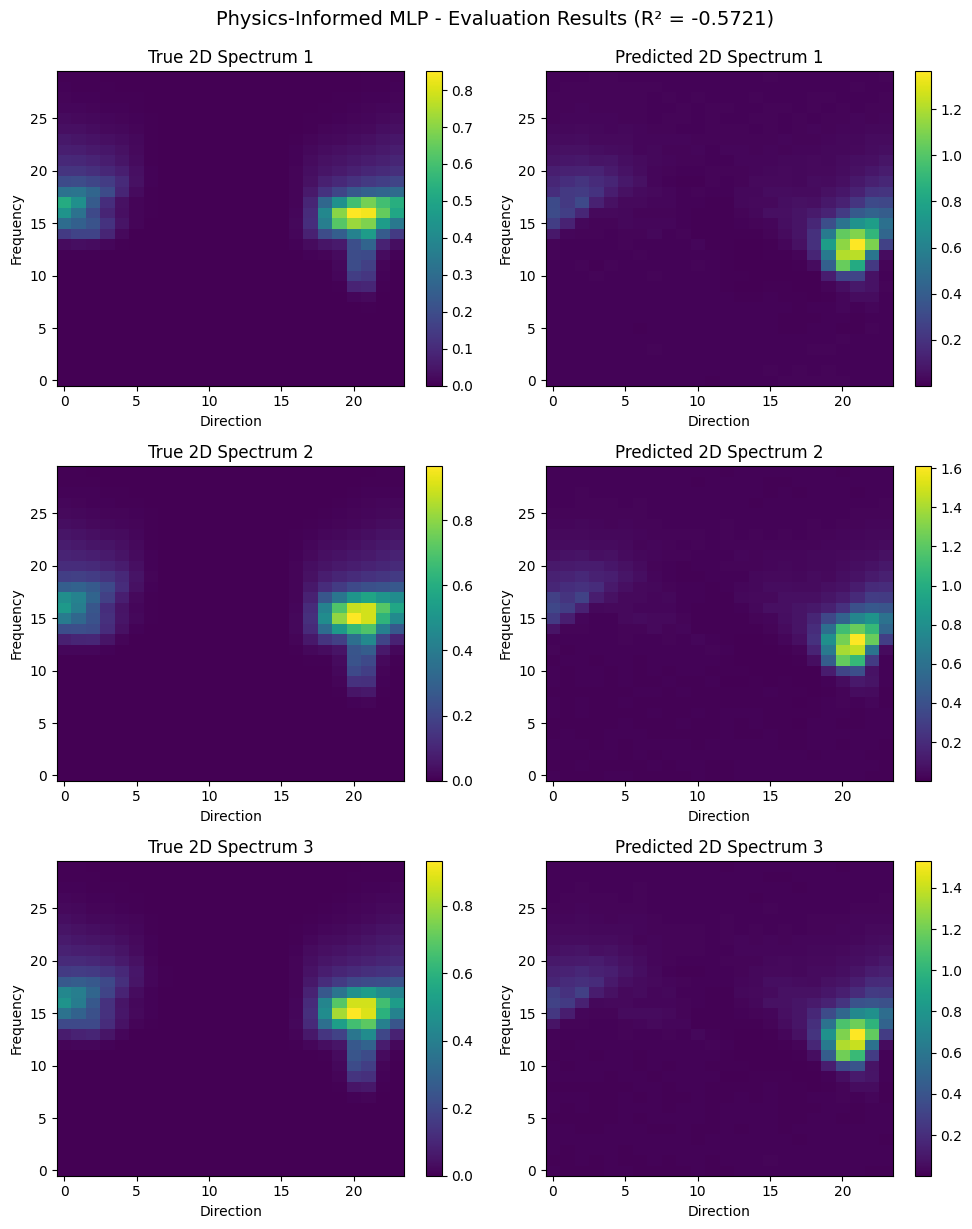

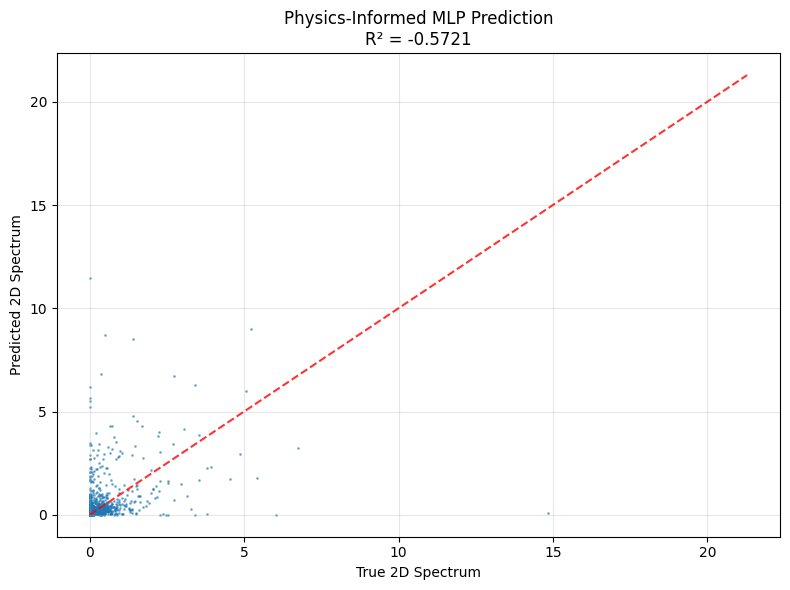


✅ Evaluation visualization complete!
Physics-Informed MLP performance: R² = -0.572129, RMSE = 4.089532e-01
Physics Loss = 1.869149e-01


In [16]:
# Visualize Physics-Informed MLP evaluation results
import matplotlib.pyplot as plt

if 'eval_results' in locals():
    
    # Select first few examples for visualization
    num_examples = min(3, eval_results['S2D_true'].shape[0])
    
    fig, axes = plt.subplots(num_examples, 2, figsize=(10, 4*num_examples))
    if num_examples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_examples):
        # True 2D spectrum
        im1 = axes[i, 0].imshow(eval_results['S2D_true'][i], aspect='auto', cmap='viridis', 
                                origin='lower', interpolation='nearest')
        axes[i, 0].set_title(f'True 2D Spectrum {i+1}')
        axes[i, 0].set_xlabel('Direction')
        axes[i, 0].set_ylabel('Frequency')
        plt.colorbar(im1, ax=axes[i, 0])
        
        # Predicted 2D spectrum  
        im2 = axes[i, 1].imshow(eval_results['S2D_pred'][i], aspect='auto', cmap='viridis',
                                origin='lower', interpolation='nearest')
        axes[i, 1].set_title(f'Predicted 2D Spectrum {i+1}')
        axes[i, 1].set_xlabel('Direction')
        axes[i, 1].set_ylabel('Frequency')
        plt.colorbar(im2, ax=axes[i, 1])
    
    plt.tight_layout()
    plt.suptitle(f'Physics-Informed MLP - Evaluation Results (R² = {eval_results["r2"]:.4f})', 
                 fontsize=14, y=1.02)
    plt.show()
    
    # Create scatter plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Scatter plot for spectra
    S2D_true_flat = eval_results['S2D_true'].reshape(-1)
    S2D_pred_flat = eval_results['S2D_pred'].reshape(-1)
    
    # Sample points for better visualization
    n_points = 10000
    indices = np.random.choice(len(S2D_true_flat), min(n_points, len(S2D_true_flat)), replace=False)
    
    ax.scatter(S2D_true_flat[indices], S2D_pred_flat[indices], alpha=0.5, s=1)
    min_val = min(S2D_true_flat.min(), S2D_pred_flat.min())
    max_val = max(S2D_true_flat.max(), S2D_pred_flat.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    ax.set_xlabel('True 2D Spectrum')
    ax.set_ylabel('Predicted 2D Spectrum')
    ax.set_title(f'Physics-Informed MLP Prediction\nR² = {eval_results["r2"]:.4f}')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Evaluation visualization complete!")
    print(f"Physics-Informed MLP performance: R² = {eval_results['r2']:.6f}, RMSE = {eval_results['rmse']:.6e}")
    print(f"Physics Loss = {eval_results['physics_loss']:.6e}")

else:
    print("❌ Evaluation results not available. Run previous cells first.")